In [1]:
import os
import cv2
import numpy as np
from PIL import Image
from collections import Counter
import json
import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

In [2]:
# =============================================================================
# STAGE 1: LOAD ALL IMAGES
# Scans merged dataset folder, returns list of (image_path, class_label)
# No quality filtering — dataset is already curated
# =============================================================================
EXCLUDE_CLASSES = {
    "brassica_juncea", "cymbopogon_citratus",
    "piper_nigrum", "trigonella_foenum_graecum"
}
def load_dataset(dataset_path):
    """
    Loads all image paths and class labels from merged dataset folder.
 
    Args:
        dataset_path: path to Merged_Dataset folder
 
    Returns:
        all_images: list of (image_path, class_label) tuples
    """
    all_images = []
    classes = sorted(os.listdir(dataset_path))
 
    for class_name in classes:
        if class_name in EXCLUDE_CLASSES:
            continue
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue
            img_path = os.path.join(class_path, img_name)
            all_images.append((img_path, class_name))
 
    print(f"Dataset loaded:")
    print(f"  Total images: {len(all_images)}")
    print(f"  Total classes: {len(classes)}")
    return all_images

In [3]:
# =============================================================================
# STAGE 2: TRAIN / VALIDATION / TEST SPLIT
# Stratified split — 85% train, 5% val, 10% test
# Split done BEFORE any augmentation or balancing
# =============================================================================
 
def split_dataset(all_images, train_ratio=0.85, val_ratio=0.05,
                  test_ratio=0.10, random_seed=42):
    """
    Stratified split into train, val, test sets.
 
    Args:
        all_images: list of (image_path, class_label)
        train_ratio: 0.85
        val_ratio: 0.05
        test_ratio: 0.10
        random_seed: 42
 
    Returns:
        train_data, val_data, test_data
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
        "Ratios must sum to 1.0"
 
    paths = [x[0] for x in all_images]
    labels = [x[1] for x in all_images]
 
    # Split train vs (val + test)
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        paths, labels,
        test_size=(val_ratio + test_ratio),
        stratify=labels,
        random_state=random_seed
    )
 
    # Split val vs test
    val_size = val_ratio / (val_ratio + test_ratio)
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temp_paths, temp_labels,
        test_size=(1 - val_size),
        stratify=temp_labels,
        random_state=random_seed
    )
 
    train_data = list(zip(train_paths, train_labels))
    val_data = list(zip(val_paths, val_labels))
    test_data = list(zip(test_paths, test_labels))
 
    print(f"\nDataset split:")
    print(f"  Training:   {len(train_data)} images")
    print(f"  Validation: {len(val_data)} images")
    print(f"  Test:       {len(test_data)} images")
 
    return train_data, val_data, test_data

In [4]:
# =============================================================================
# STAGE 3: CLAHE HISTOGRAM EQUALIZATION (Custom Transform)
# Applied to ALL splits — train, val, test, inference
# Improves contrast and visibility of leaf veins and texture
# Applied on L channel of LAB color space to avoid color distortion
# =============================================================================
 
class HistogramEqualization:
    """
    CLAHE on L channel of LAB color space.
    Improves local contrast without over-brightening.
    Better than global histogram equalization for leaf images.
    """
    def __init__(self, clip_limit=2.0, tile_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_size = tile_size
 
    def __call__(self, img):
        img_array = np.array(img)
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
        img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
 
        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_size
        )
        img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
 
        img_bgr = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
 
        return Image.fromarray(img_rgb)

In [5]:
# =============================================================================
# BASE PIPELINE — applied to everything (train, val, test, inference)
# Steps: Resize → RGB → CLAHE → ToTensor → Normalize
# =============================================================================
 
base_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    HistogramEqualization(clip_limit=2.0, tile_size=(8, 8)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats for pretrained models
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# =============================================================================
# TRAIN PIPELINE — base + augmentation
# Augmentation applied ON THE FLY during training (not saved to disk)
# Each epoch the same image looks slightly different
# =============================================================================
 
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)), # Slightly larger initial resize gives room to crop
    transforms.Lambda(lambda img: img.convert('RGB')),
    HistogramEqualization(clip_limit=2.0, tile_size=(8, 8)),

    # --- Augmentation (training only) ---
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    # Your Fix is here: Rotate, then CenterCrop to remove corners, then Resize to final 224
    transforms.RandomRotation(degrees=32, fill=(255, 255, 255)),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=20, scale=(0.8, 1.2), fill=(255, 255, 255)),
    transforms.CenterCrop(224),
    
    
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),
    # ------------------------------------

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
 
# Val and test — no augmentation
test_transforms = base_transforms
inference_transforms = base_transforms

In [7]:
# =============================================================================
# STAGE 4: CLASS BALANCING WITH OVERSAMPLING
# Applied to training set only
# Target: all classes have exactly target_count images
# Oversampling: 
# Undersampling: randomly remove images above target
# =============================================================================
 
def balance_classes(train_data, target_count=150,random_seed=42):
    """
    Balances all classes to target_count images.
    - Oversampling: 
    - Undersampling: randomly removes excess images
 
    Args:
        train_data: list of (image_path, class_label)
        target_count: target number of images per class (default 150)
        random_seed: for reproducibility
 
    Returns:
        balanced_data: balanced list of (image_path, class_label)
    """
    np.random.seed(random_seed)
    class_groups = {}
    for path, label in train_data:
        if label not in class_groups:
            class_groups[label] = []
        class_groups[label].append(path)

    balanced_data = []
    for label, paths in class_groups.items():
        n = len(paths)
        if n < target_count:
            # Duplicate paths. train_transforms will uniquely augment them in RAM.
            extra_needed = target_count - n
            extra_paths = [paths[i % n] for i in range(extra_needed)]
            balanced_data.extend([(p, label) for p in (paths + extra_paths)])
        elif n > target_count:
            selected = list(np.random.choice(paths, target_count, replace=False))
            balanced_data.extend([(p, label) for p in selected])
        else:
            balanced_data.extend([(p, label) for p in paths])

    
    from collections import Counter
    class_counts = Counter([x[1] for x in balanced_data])
    print(f"\nClass balancing complete (In-Memory Path Duplication):")
    print(f"  Target per class: {target_count}")
    print(f"  Total training images: {len(balanced_data)}")
    print(f"  Min per class: {min(class_counts.values())}")
    print(f"  Max per class: {max(class_counts.values())}")

    return balanced_data

In [8]:
# =============================================================================
# STAGE 5: DATASET CLASS WITH LABEL ENCODING
# =============================================================================
 
class MedicinalPlantDataset(Dataset):
    """
    PyTorch Dataset for Medicinal Plant images.
    Returns image tensor + integer label + one-hot label.
    """
    def __init__(self, data, class_to_idx, transform=None):
        self.data = data
        self.class_to_idx = class_to_idx
        self.num_classes = len(class_to_idx)
        self.transform = transform
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        img_path, class_name = self.data[idx]
 
        image = Image.open(img_path).convert('RGB')
 
        if self.transform:
            image = self.transform(image)
 
        int_label = torch.tensor(self.class_to_idx[class_name], dtype=torch.long)
 
        one_hot_label = torch.zeros(self.num_classes)
        one_hot_label[int_label] = 1.0
 
        return image, int_label, one_hot_label

In [9]:
# =============================================================================
# MAIN PIPELINE — builds all dataloaders
# =============================================================================
 
def build_dataloaders(dataset_path, batch_size=32, num_workers=4,
                      target_count=150):
    """
    Complete pipeline returning train, val, test DataLoaders.
 
    Args:
        dataset_path: path to Merged_Dataset folder
        batch_size: 32
        num_workers: 4
        target_count: target images per class after balancing (default 150)
 
    Returns:
        train_loader, val_loader, test_loader, class_to_idx
    """
 
    # Stage 1: Load dataset
    print("=" * 50)
    print("STAGE 1: Loading Dataset")
    print("=" * 50)
    all_images = load_dataset(dataset_path)
 
    # Stage 2: Split
    print("\n" + "=" * 50)
    print("STAGE 2: Train/Val/Test Split (85/5/10)")
    print("=" * 50)
    train_data, val_data, test_data = split_dataset(all_images)
 
    # Build class mapping
    all_classes = sorted(set([x[1] for x in all_images]))
    class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}
    print(f"\nTotal classes: {len(class_to_idx)}")
 
    # Stage 4: Balance training set
    print("\n" + "=" * 50)
    print("STAGE 4: Class Balancing (Training only)")
    print("=" * 50)
    train_data = balance_classes(train_data, target_count=target_count)
 
    # Stage 5: Create datasets
    print("\n" + "=" * 50)
    print("STAGE 5: Creating Datasets and DataLoaders")
    print("=" * 50)
 
    train_dataset = MedicinalPlantDataset(
        data=train_data,
        class_to_idx=class_to_idx,
        transform=train_transforms
    )
 
    val_dataset = MedicinalPlantDataset(
        data=val_data,
        class_to_idx=class_to_idx,
        transform=test_transforms
    )
 
    test_dataset = MedicinalPlantDataset(
        data=test_data,
        class_to_idx=class_to_idx,
        transform=test_transforms
    )
 
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
 
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
 
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
 
    print(f"\nDataLoaders ready:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches:   {len(val_loader)}")
    print(f"  Test batches:  {len(test_loader)}")
 
    return train_loader, val_loader, test_loader, class_to_idx

In [10]:
# =============================================================================
# STAGE 7: EVALUATION FUNCTION
# =============================================================================
def evaluate_on_test(model, test_loader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            outputs = model(inputs.to(device))
            running_corrects += torch.sum(torch.max(outputs, 1)[1] == labels.to(device).data)
    
    acc = running_corrects.double() / len(test_loader.dataset)
    print(f"Final Test Accuracy: {acc:.4f} ({(acc*100):.2f}%)\n")

In [11]:
import torch
from torchvision import models
model = models.efficientnet_b0(weights=None)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [12]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models


def train_efficientnet(train_loader, val_loader, num_classes, frozen_epochs=3, unfrozen_epochs=15):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")

    # 1. Load pre-trained EfficientNet-B0
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # 2. Modify the classifier head
    # EfficientNet-B0's classifier is Sequential([Dropout, Linear])
    # so in_features lives on index [1], not on classifier itself
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    start_time = time.time()

    # ==========================================
    # PHASE 1: FROZEN (Warm-up)
    # ==========================================
    print("\n" + "=" * 50)
    print(f"PHASE 1: TRAINING CLASSIFIER ONLY ({frozen_epochs} Epochs)")
    print("=" * 50)

    for param in model.features.parameters():
        param.requires_grad = False

    optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

    # Receive updated best_acc and best_model_wts from Phase 1
    model, best_acc, best_model_wts = run_training_loop(
        model, train_loader, val_loader, criterion, optimizer,
        device, frozen_epochs, best_acc, best_model_wts
    )

    # ==========================================
    # PHASE 2: UNFROZEN (Fine-tuning)
    # ==========================================
    print("\n" + "=" * 50)
    print(f"PHASE 2: FINE-TUNING ENTIRE NETWORK ({unfrozen_epochs} Epochs)")
    print("=" * 50)

    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=1e-5)

    # Pass best_acc and best_model_wts forward so Phase 2 compares
    # against the true best from Phase 1, not a reset 0.0
    model, best_acc, best_model_wts = run_training_loop(
        model, train_loader, val_loader, criterion, optimizer,
        device, unfrozen_epochs, best_acc, best_model_wts,
        start_epoch=frozen_epochs
    )

    # Load the truly best weights across both phases
    model.load_state_dict(best_model_wts)

    time_elapsed = time.time() - start_time
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best overall val accuracy: {best_acc:.4f}')
    return model


def run_training_loop(model, train_loader, val_loader, criterion, optimizer,
                      device, num_epochs, best_acc, best_model_wts, start_epoch=0):
    for epoch in range(num_epochs):
        print(f'Epoch {start_epoch + epoch + 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Unpack only 2 values; drop the third if your dataset returns one
            for inputs, labels, _ in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    # Return all three so the caller can carry state across phases
    return model, best_acc, best_model_wts

In [13]:
if __name__ == "__main__":
    DATASET_PATH = '/kaggle/input/datasets/saitejaswinichikoti/merged-dataset'

    # 1. Run Preprocessing & Get DataLoaders
    # IMPORTANT: Ensure your transforms resize images to 224x224 for EfficientNet
    train_loader, val_loader, test_loader, class_to_idx = build_dataloaders(
        dataset_path=DATASET_PATH,
        batch_size=32,
        num_workers=4,
        target_count=150
    )

    # 2. Train EfficientNet-B0 (3 Frozen + 15 Unfrozen)
    num_classes = len(class_to_idx)

    best_efficientnet = train_efficientnet(
        train_loader=train_loader, 
        val_loader=val_loader, 
        num_classes=num_classes, 
        frozen_epochs=3, 
        unfrozen_epochs=15
    )

    # 3. Final Test Evaluation
    print("\n" + "="*50)
    print("FINAL TEST EVALUATION (EFFICIENTNET)")
    print("="*50)
    # Re-use your evaluation function
    evaluate_on_test(best_efficientnet, test_loader)

    # 4. Save the Trained Model
    torch.save(best_efficientnet.state_dict(), 'efficientnet_medicinal_plants.pth')
    print("Model saved successfully as 'efficientnet_efficientnet_plants.pth'")

STAGE 1: Loading Dataset
Dataset loaded:
  Total images: 10579
  Total classes: 97

STAGE 2: Train/Val/Test Split (85/5/10)

Dataset split:
  Training:   8992 images
  Validation: 528 images
  Test:       1059 images

Total classes: 93

STAGE 4: Class Balancing (Training only)

Class balancing complete (In-Memory Path Duplication):
  Target per class: 150
  Total training images: 13950
  Min per class: 150
  Max per class: 150

STAGE 5: Creating Datasets and DataLoaders

DataLoaders ready:
  Train batches: 436
  Val batches:   17
  Test batches:  34
Training on device: cuda:0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 227MB/s]



PHASE 1: TRAINING CLASSIFIER ONLY (3 Epochs)
Epoch 1
----------
Train Loss: 2.2766 Acc: 0.5551
Val Loss: 1.6570 Acc: 0.6269

Epoch 2
----------
Train Loss: 1.1623 Acc: 0.7430
Val Loss: 1.2618 Acc: 0.6875

Epoch 3
----------
Train Loss: 0.9072 Acc: 0.7873
Val Loss: 1.0768 Acc: 0.7083


PHASE 2: FINE-TUNING ENTIRE NETWORK (15 Epochs)
Epoch 4
----------
Train Loss: 0.6472 Acc: 0.8459
Val Loss: 0.8077 Acc: 0.7708

Epoch 5
----------
Train Loss: 0.5050 Acc: 0.8768
Val Loss: 0.7114 Acc: 0.8049

Epoch 6
----------
Train Loss: 0.4347 Acc: 0.8931
Val Loss: 0.6215 Acc: 0.8258

Epoch 7
----------
Train Loss: 0.3741 Acc: 0.9072
Val Loss: 0.5526 Acc: 0.8371

Epoch 8
----------
Train Loss: 0.3310 Acc: 0.9198
Val Loss: 0.5064 Acc: 0.8598

Epoch 9
----------
Train Loss: 0.3000 Acc: 0.9227
Val Loss: 0.4581 Acc: 0.8731

Epoch 10
----------
Train Loss: 0.2665 Acc: 0.9319
Val Loss: 0.4409 Acc: 0.8750

Epoch 11
----------
Train Loss: 0.2439 Acc: 0.9407
Val Loss: 0.4037 Acc: 0.8883

Epoch 12
----------
Tra

In [14]:
import json

# Create the Number -> Name mapping
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Save with your specific filename
mapping_filename = "class_mapping_efficientnet.json"

with open(mapping_filename, "w") as f:
    json.dump(idx_to_class, f, indent=2)

print(f"✅ Success! {mapping_filename} created in working directory.")

✅ Success! class_mapping_efficientnet.json created in working directory.


In [15]:
from sklearn.metrics import precision_recall_fscore_support, fbeta_score, classification_report
import numpy as np

def evaluate_comprehensive_metrics(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate Global Metrics
    # Average='macro' calculates the metric for each label and finds their unweighted mean.
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    
    # F2-score (beta=2) gives more weight to Recall (minimizing false negatives)
    f2 = fbeta_score(all_labels, all_preds, beta=2, average='macro')

    print("="*50)
    print("GLOBAL PERFORMANCE METRICS (TEST SET)")
    print("="*50)
    print(f"Overall Accuracy:  {np.mean(np.array(all_preds) == np.array(all_labels)):.4f}")
    print(f"Macro Precision:   {precision:.4f}")
    print(f"Macro Recall:      {recall:.4f}")
    print(f"Macro F1-Score:    {f1:.4f}")
    print(f"Macro F2-Score:    {f2:.4f}")
    print("="*50)

    # If you want to see which specific plants the model struggled with:
    # print(classification_report(all_labels, all_preds, target_names=list(class_to_idx.keys())))

# Execute
evaluate_comprehensive_metrics(best_efficientnet, test_loader)

GLOBAL PERFORMANCE METRICS (TEST SET)
Overall Accuracy:  0.9415
Macro Precision:   0.9441
Macro Recall:      0.9585
Macro F1-Score:    0.9471
Macro F2-Score:    0.9529


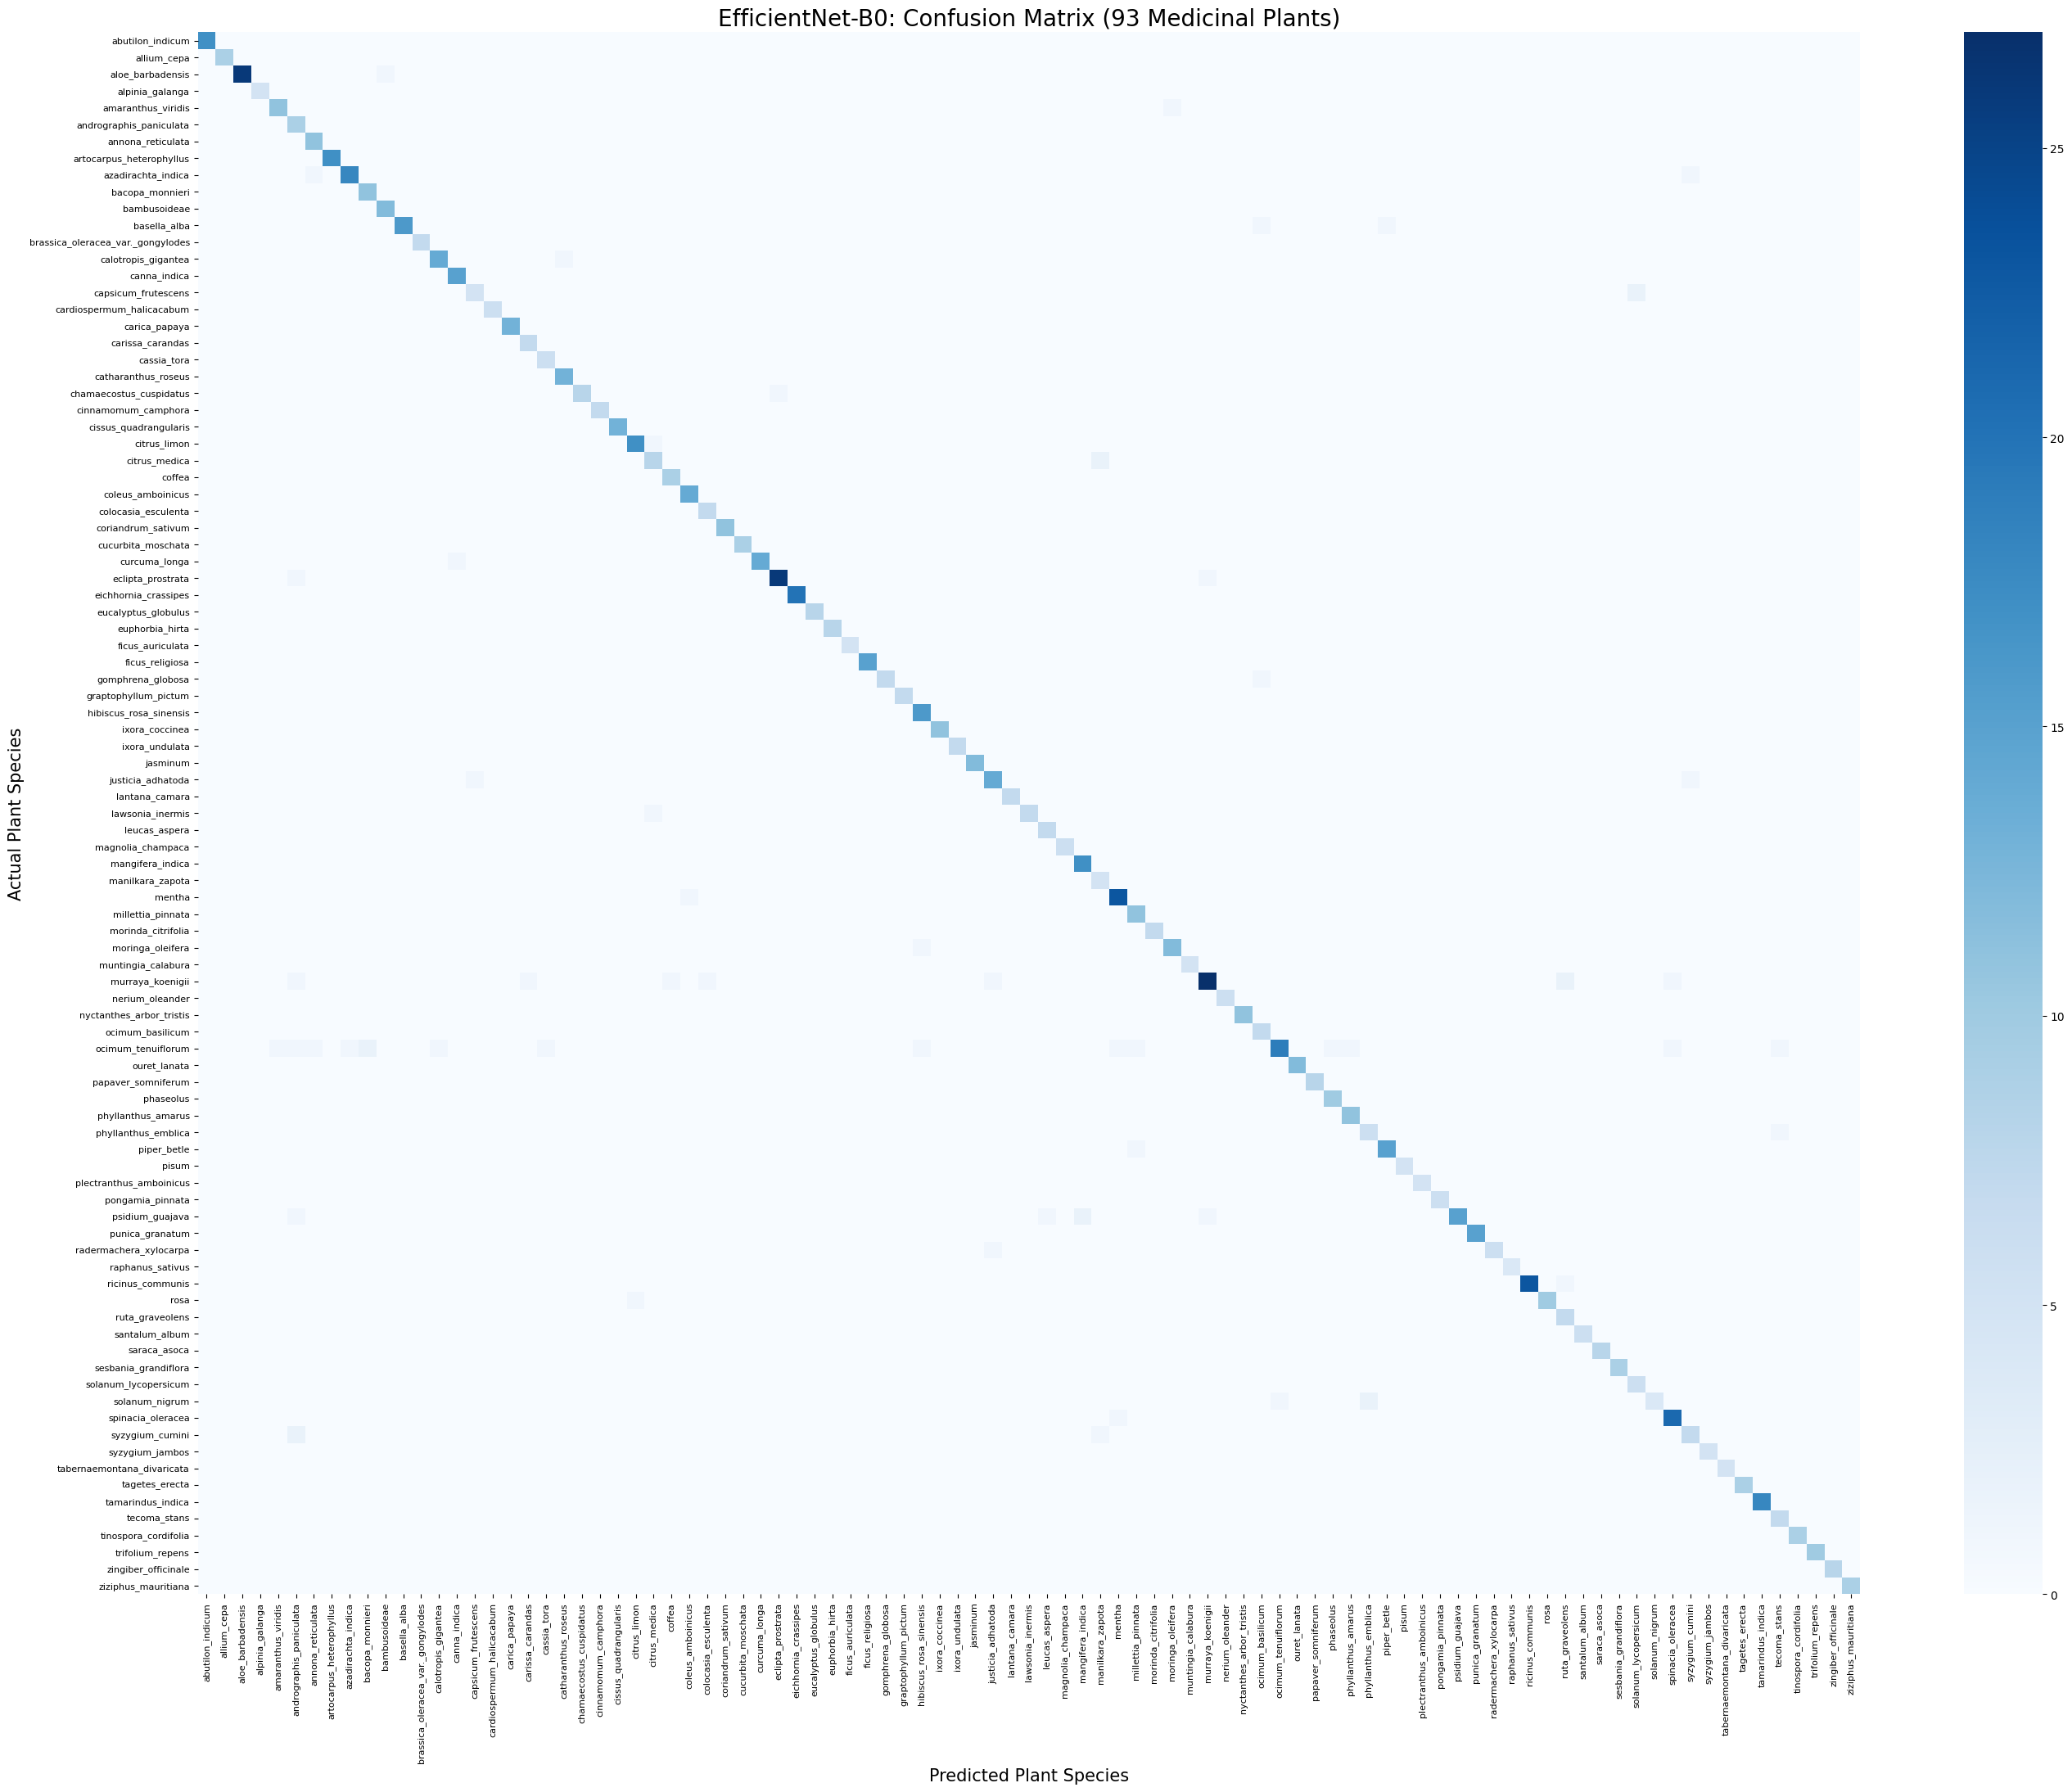

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_styled_confusion_matrix(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    
    # Huge figure size because 93 classes need room
    plt.figure(figsize=(28, 22)) 
    
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('EfficientNet-B0: Confusion Matrix (93 Medicinal Plants)', fontsize=20)
    plt.xlabel('Predicted Plant Species', fontsize=15)
    plt.ylabel('Actual Plant Species', fontsize=15)
    
    # Rotate labels so they don't overlap
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    
    plt.tight_layout()
    plt.savefig('confusion_matrix_efficientnet.png', dpi=300)
    plt.show()

# Execute
# Use class_to_idx keys (the names) for the labels
plant_names = list(class_to_idx.keys())
plot_styled_confusion_matrix(best_efficientnet, test_loader, plant_names)